In [1]:
import rawpy
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, ExifTags
import numpy as np
import cv2


### Deliverable 3-5

In [70]:
imageFolder = Path("images")
imageFiles = sorted(imageFolder.glob("*.dng"))

imagePath = imageFiles[0]
print(f"Opening: {imagePath.resolve()}")
with rawpy.imread(str(imagePath)) as raw:
    print(f"Raw Type: {raw.raw_type}")
    print(f"Raw Shape: {raw.raw_image_visible.shape}")
    print(f"Raw Dtype: {raw.raw_image_visible.dtype}")
    print(f"Raw Pattern: {raw.raw_pattern}")
    print(f"Color Description: {raw.color_desc}")
    print(f"Black Level Per Channel: {raw.black_level_per_channel}")
    print(f"White Level: {raw.white_level}")
#     rgb = raw.postprocess(use_camera_wb=True)

# print(f"RGB shape: {rgb.shape}, dtype: {rgb.dtype}")
# plt.figure(figsize=(10, 8))
# plt.imshow(rgb)
# plt.axis("off")
# plt.show()

Opening: C:\Users\EMMWILL\repos\EE513\exercises\01_assignment\images\1F55F4EC-7F8E-4395-8CF9-C1CE2F7BA83D.dng
Raw Type: RawType.Flat
Raw Shape: (3024, 4032)
Raw Dtype: uint16
Raw Pattern: [[2 3]
 [1 0]]
Color Description: b'RGBG'
Black Level Per Channel: [528, 528, 528, 528]
White Level: 4095


### Deliverable 6-8

Opening: C:\Users\EMMWILL\repos\EE513\exercises\01_assignment\images\water2.dng
Raw Type: RawType.Flat
Raw Shape: (3024, 4032)
Raw Dtype: uint16
Raw Pattern: [[2 3]
 [1 0]]
Color Description: b'RGBG'
Black Level Per Channel: [528, 528, 528, 528]
White Level: 4095
Raw Colors: 3
RGB shape: (4032, 3024, 3), dtype: uint8


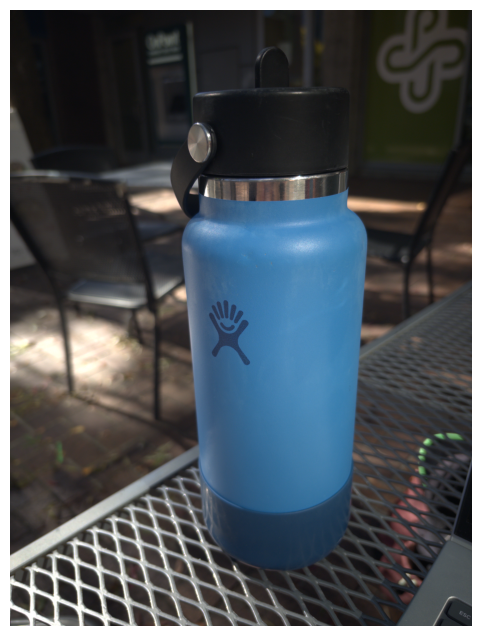

White Level: 4095
Hardware Bit Depth: 12-bit


In [71]:
imageFiles = sorted(imageFolder.glob("water2.dng"))

imagePath = imageFiles[0]
print(f"Opening: {imagePath.resolve()}")
with rawpy.imread(str(imagePath)) as raw:
    print(f"Raw Type: {raw.raw_type}")
    print(f"Raw Shape: {raw.raw_image_visible.shape}")
    print(f"Raw Dtype: {raw.raw_image_visible.dtype}")
    print(f"Raw Pattern: {raw.raw_pattern}")
    print(f"Color Description: {raw.color_desc}")
    print(f"Black Level Per Channel: {raw.black_level_per_channel}")
    print(f"White Level: {raw.white_level}")
    print(f"Raw Colors: {raw.num_colors}")
    rgb = raw.postprocess(use_camera_wb=True)

print(f"RGB shape: {rgb.shape}, dtype: {rgb.dtype}")
plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.axis("off")
plt.show()
    
    
with rawpy.imread(str(imagePath)) as raw:
    # Get the sensor saturation value
    white_level = raw.white_level
    
    # Calculate the bit depth based on the white level
    bit_depth = white_level.bit_length()

print(f"White Level: {white_level}")
print(f"Hardware Bit Depth: {bit_depth}-bit")

In [48]:
imagePath = imageFolder / "water1.jpeg"

with Image.open(imagePath) as image:
    pixels = np.array(image)
    print(f"Format: {image.format}\n")
    print(f"Color Mode: {image.mode}\n")
    print(f"Shape: {pixels.shape}\n")
    print(f"Dtype: {pixels.dtype}")

Format: MPO

Color Mode: RGB

Shape: (4284, 5712, 3)

Dtype: uint8


In [73]:
imagePath = imageFolder / "water1.jpeg"
rotatedPath = imageFolder / "water1_rotated.png"

with Image.open(imagePath) as image:
    rotatedImage = image.convert("RGB").rotate(-90, expand=True)
    rotatedImage.save(rotatedPath)

print(f"Saved 90-degree clockwise rotation: {rotatedPath}")
print(f"Rotated dimensions: {rotatedImage.width}x{rotatedImage.height}")

Saved 90-degree clockwise rotation: images\water1_rotated.png
Rotated dimensions: 4284x5712


In [105]:
cropSize = 30
zoomFactor = 10
cropCoordinates = {
    "water1_rotated.png": (1842, 2540),  # (x, y) upper-left crop corner
    "water2.dng":(1398, 1895),
}

for imageName, (cropX, cropY) in cropCoordinates.items():
    imagePath = imageFolder / imageName

    if imagePath.suffix.lower() == ".dng":
        with rawpy.imread(str(imagePath)) as raw:
            pixels = raw.postprocess(use_camera_wb=True)
        image = Image.fromarray(pixels)
    else:
        with Image.open(imagePath) as sourceImage:
            image = sourceImage.convert("RGB")

    if (
        cropX < 0
        or cropY < 0
        or cropX + cropSize > image.width
        or cropY + cropSize > image.height
    ):
        raise ValueError(f"Crop at ({cropX}, {cropY}) does not fit in {imageName}")

    crop = image.crop((cropX, cropY, cropX + cropSize, cropY + cropSize))
    zoomed = crop.resize(
        (cropSize * zoomFactor, cropSize * zoomFactor),
        Image.Resampling.NEAREST,
    )

    outputPath = imageFolder / f"{imagePath.stem}_zoomed.png"
    zoomed.save(outputPath)
    print(
        f"Saved {cropSize}x{cropSize} crop at ({cropX}, {cropY}), "
        f"enlarged {zoomFactor}x: {outputPath}"
    )

Saved 30x30 crop at (1842, 2540), enlarged 10x: images\water1_rotated_zoomed.png
Saved 30x30 crop at (1398, 1895), enlarged 10x: images\water2_zoomed.png


### Deliberable 9-12

Saved 3x5 contact sheet with 15 images: images\cb_contact_sheet.png


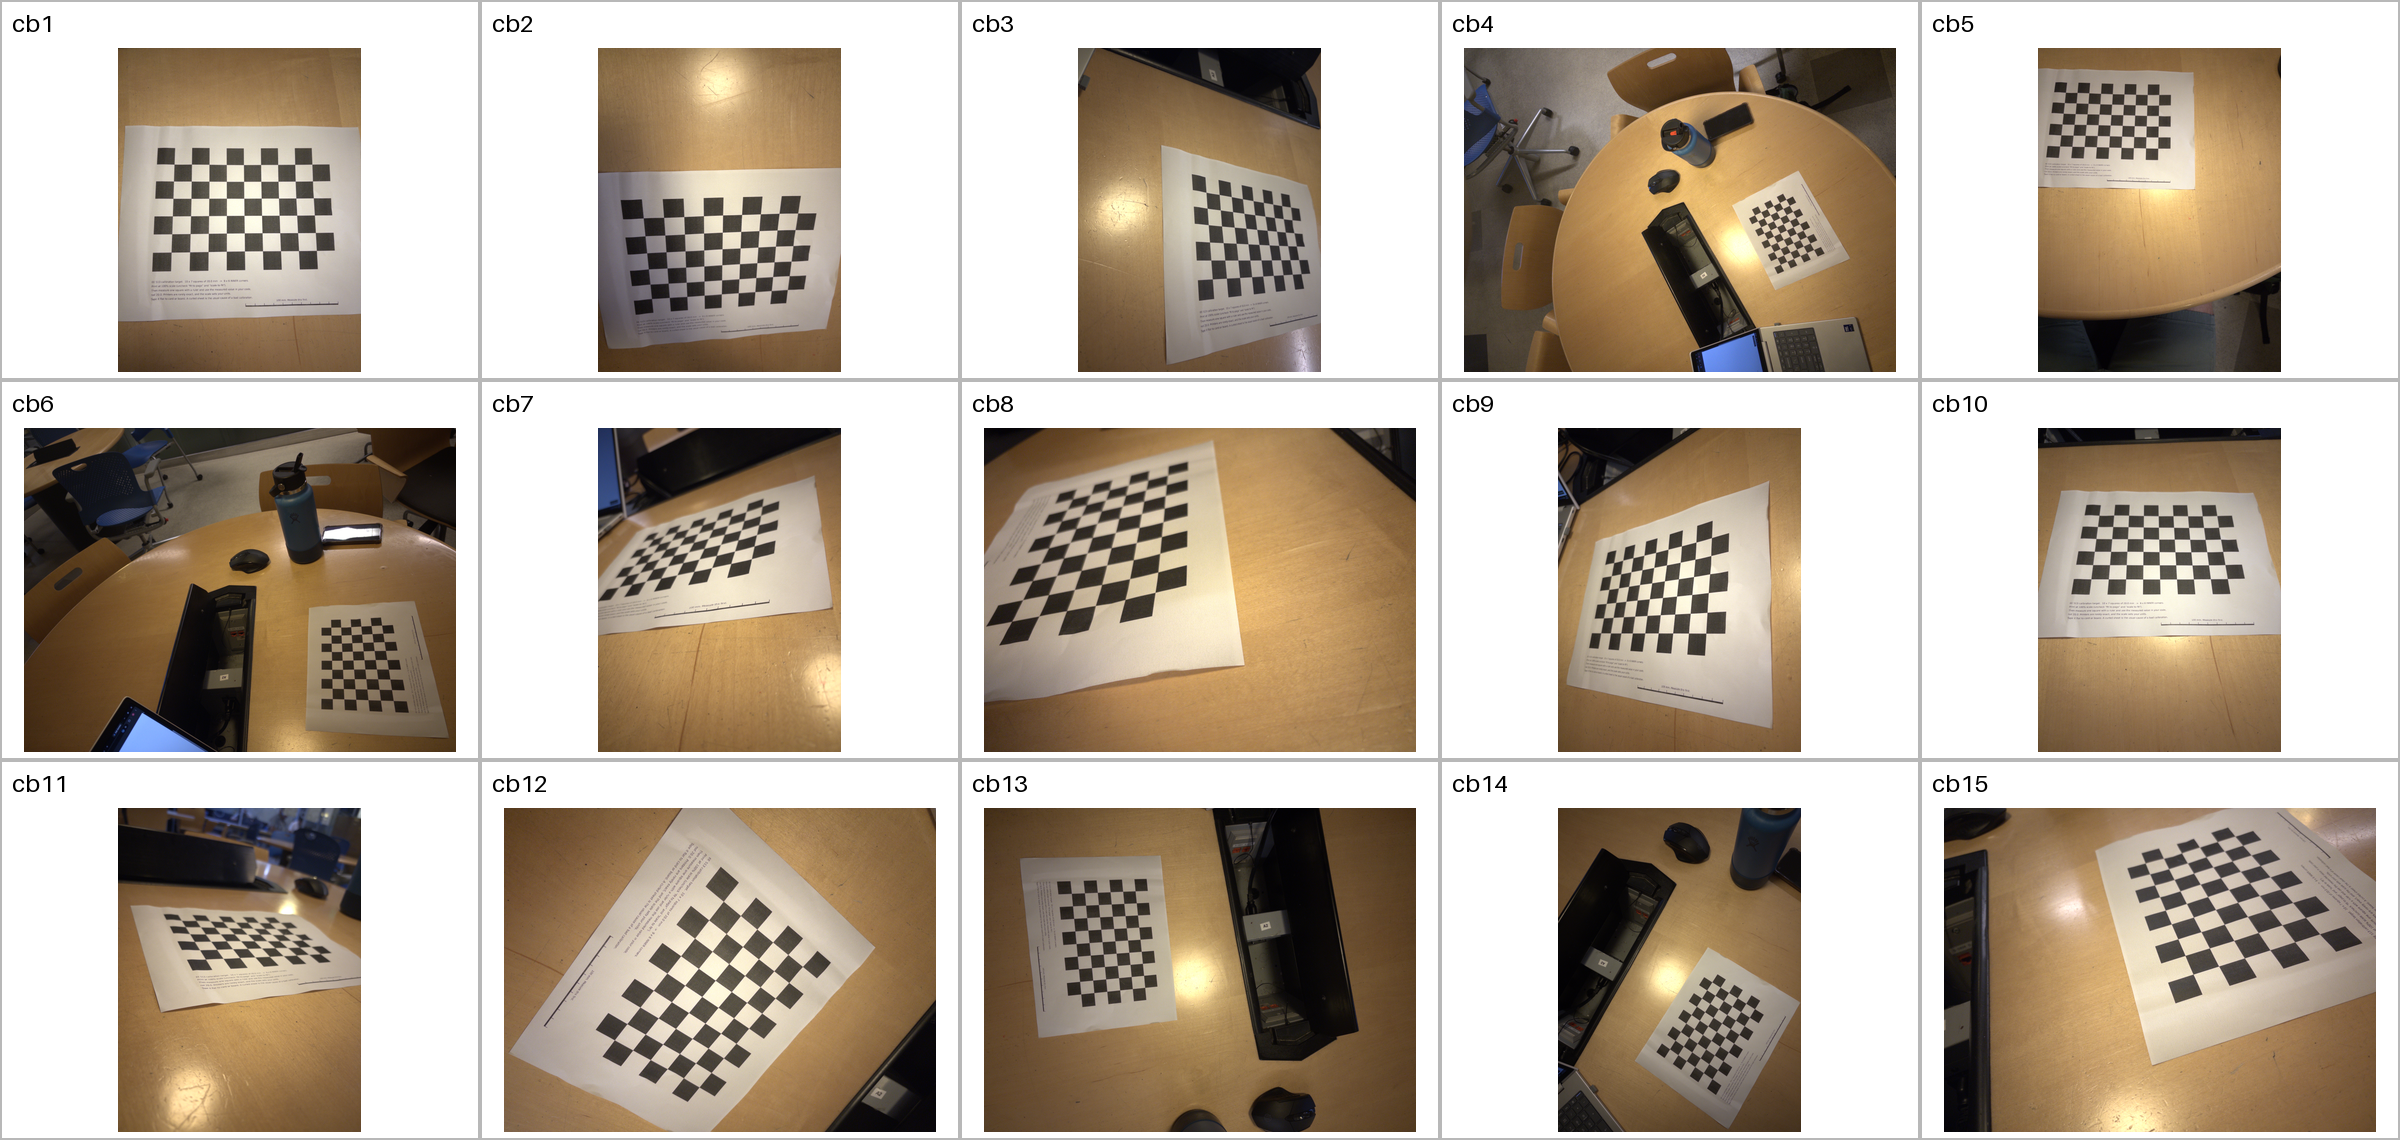

In [5]:
from PIL import ImageDraw, ImageFont
imageFolder = Path("images")
imagePaths = sorted(
    imageFolder.glob("cb*.DNG"),
    key=lambda imagePath: int(imagePath.stem[2:]),
)
expectedNames = {f"cb{index}.DNG" for index in range(1, 16)}
if {imagePath.name for imagePath in imagePaths} != expectedNames:
    raise FileNotFoundError("Expected cb1.DNG through cb15.DNG in the images folder")

columns = 5
rows = 3
tileWidth = 480
tileHeight = 380
labelHeight = 40
sheet = Image.new("RGB", (columns * tileWidth, rows * tileHeight), "white")
draw = ImageDraw.Draw(sheet)
font = ImageFont.load_default(size=24)

for index, imagePath in enumerate(imagePaths):
    with rawpy.imread(str(imagePath)) as raw:
        pixels = raw.postprocess(use_camera_wb=True)

    image = Image.fromarray(pixels)
    image.thumbnail(
        (tileWidth - 24, tileHeight - labelHeight - 16),
        Image.Resampling.LANCZOS,
    )

    column = index % columns
    row = index // columns
    left = column * tileWidth
    top = row * tileHeight
    draw.text((left + 12, top + 8), imagePath.stem, fill="black", font=font)
    imageLeft = left + (tileWidth - image.width) // 2
    imageTop = top + labelHeight + (tileHeight - labelHeight - image.height) // 2
    sheet.paste(image, (imageLeft, imageTop))
    draw.rectangle(
        (left, top, left + tileWidth - 1, top + tileHeight - 1),
        outline="#b8b8b8",
        width=2,
    )

contactSheetPath = imageFolder / "cb_contact_sheet.png"
sheet.save(contactSheetPath)
print(f"Saved 3x5 contact sheet with {len(imagePaths)} images: {contactSheetPath}")
display(sheet)

In [12]:
imageFolder = Path("images")
imagePaths = sorted(
    imageFolder.glob("cb*.DNG"),
    key=lambda imagePath: int(imagePath.stem[2:]),
)

boardSize = (9, 6)
objp = np.zeros((boardSize[0] * boardSize[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:boardSize[0], 0:boardSize[1]].T.reshape(-1, 2)

objpoints = []
imgpoints = []

for index, imagePath in enumerate(imagePaths):
    if index not in (6, 7, 10):
        with rawpy.imread(str(imagePath)) as raw:
            rgb = raw.postprocess()

        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        ret, corners = cv2.findChessboardCorners(bgr, boardSize, None)

        if ret:
            print(f"Chessboard corners found for {imagePath.name}.")
            cv2.drawChessboardCorners(bgr, boardSize, corners, ret)
            objpoints.append(objp.copy())

            gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
            corners = cv2.cornerSubPix(
                gray,
                corners,
                (11, 11),
                (-1, -1),
                criteria=(
                    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
                    30,
                    0.001,
                ),
            )
            imgpoints.append(corners)
            # outputPath = imageFolder / f"{imagePath.stem}_corners.png"
            # if not cv2.imwrite(str(outputPath), bgr):
            #     raise OSError(f"Could not save annotated image to {outputPath}")
            # print(f"Saved annotated chessboard image: {outputPath}")

            # maxWidth, maxHeight = 1400, 900
            # displayScale = min(
            #     maxWidth / bgr.shape[1],
            #     maxHeight / bgr.shape[0],
            #     1.0,
            # )
            # preview = cv2.resize(
            #     bgr,
            #     None,
            #     fx=displayScale,
            #     fy=displayScale,
            #     interpolation=cv2.INTER_AREA,
            # )
            # display(Image.fromarray(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)))
        else:
            print(f"Chessboard corners not found for {imagePath.name}.")

Chessboard corners found for cb1.DNG.
Chessboard corners found for cb2.DNG.
Chessboard corners found for cb3.DNG.
Chessboard corners found for cb4.DNG.
Chessboard corners found for cb5.DNG.
Chessboard corners found for cb6.DNG.
Chessboard corners found for cb9.DNG.
Chessboard corners found for cb10.DNG.
Chessboard corners found for cb12.DNG.
Chessboard corners found for cb13.DNG.
Chessboard corners found for cb14.DNG.
Chessboard corners found for cb15.DNG.


In [18]:
imageSize = (bgr.shape[1], bgr.shape[0])
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, imageSize, None, None
)

mean_error = 0
for i in range(len(objpoints)):
    imgpoints2, _ = cv2.projectPoints(
        objpoints[i], rvecs[i], tvecs[i], mtx, dist
    )
    observed = imgpoints[i].reshape(-1, 2)
    projected = imgpoints2.reshape(-1, 2)
    error = cv2.norm(observed, projected, cv2.NORM_L2) / len(projected)
    mean_error += error

mean_error /= len(objpoints)
print(f"Total reprojection error: {mean_error}")

Total reprojection error: 0.5281966633174496
